# Transient heat equation on a U-shaped domain — AlphaPINN spectral PINN

**PDE:**  $\partial_t u - \kappa\,\Delta u = 0$  (heat / diffusion)

**Domain:**  $[0,2]\times[0,2]$ minus a notch $(x\in(0.6,1.4),\; y>0.8)$,  time $t\in[0,T]$

**Initial condition:**  $u(x,y,0) = 0$

**Boundary conditions:**
- $u = 1$ on the **left-arm top** ($y=2,\; x\in[0,0.6]$) — hot, held for all $t$
- $u = 0$ everywhere else on the boundary — cold, held for all $t$

**Method:**  **AlphaPINN — global spectral PINN without Method of Lines.**

Since the Laplace eigenvectors $\Phi$ are global spatial modes, the full
space-time solution can be written as:

$$u(x,t) = \Phi\,\alpha(t), \quad \alpha(t) = \text{FNN}(t) \in \mathbb{R}^K$$

The FNN takes only $t$ as input and outputs the spectral expansion coefficients.
Time derivatives follow by autodiff; no state, no rollout, no BPTT.

Physics is enforced through the Galerkin weak-form residual:

$$\int_\Omega \phi\,\partial_t u\,d\Omega + \kappa\int_\Omega \nabla u\cdot\nabla\phi\,d\Omega = 0 \quad \forall\,\phi\in V_h, \; t\in[0,T]$$

The IC $u(\cdot,0)=0$ is added as a Dirichlet BC on the $t=0$ face of the domain.


## 1. Imports & environment

In [1]:
import pinns
import jax.numpy as jnp
import numpy as np

import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt

X_MAX = 2
Y_MAX = 2
KAPPA = 1

## 2. Build the U-shaped triangulated mesh

<Axes: title={'center': 'spatial'}, xlabel='x', ylabel='y'>

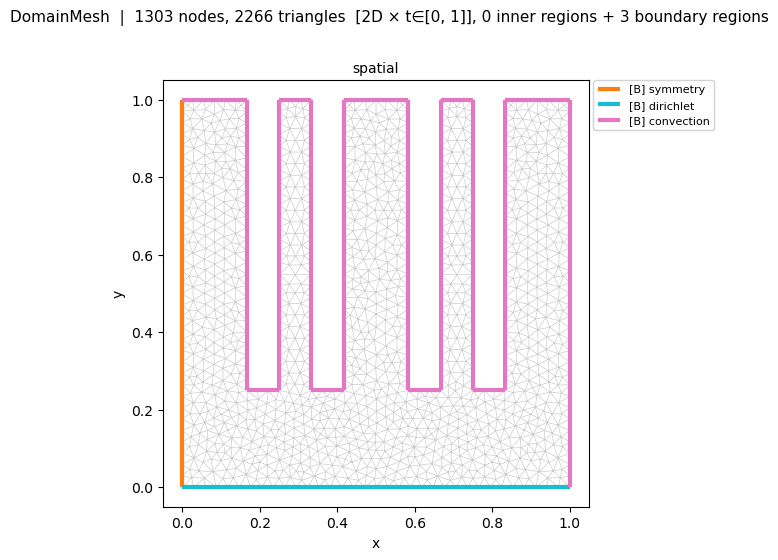

In [9]:
mesh = pinns.meshes.trident(mesh_size=0.03)

domain = pinns.domain.DomainMesh(mesh, time=(0,1))

domain.add_boundary(lambda X: (X[:, 0] < 0.01), "symmetry")
domain.add_boundary(lambda X: (X[:, 1] < 0.01), "dirichlet")
domain.add_boundary(lambda X: ~((X[:, 0] < 0.01) | (X[:, 1] < 0.01)) | (X[:, 0] + X[:, 1] > 0.99), "convection")

domain.plot(boundary="custom", backend="matplotlib")

## 6. PDE problem & AlphaPINN network

$$\int_\Omega \phi\,\partial_t u\,d\Omega + \kappa\int_\Omega \nabla u\cdot\nabla\phi\,d\Omega = 0$$

**Design:**  `ProblemWeak` is always defined **before** the network — it owns
the `output_transform` that enforces Dirichlet BCs and the IC ramp at every query point.
The network receives it as a constructor argument:

```python
problem = ProblemWeak(..., hard_constraints=["bc_name", ...])
net     = Network(domain, ..., output_transform=problem.output_transform)
```

This pattern is **identical** for continuous and state-integrator modes, and for
both `AlphaPINN` and `GNNMeshNetwork`.  In state-integrator mode the network also
clamps BC nodes internally before storing $u^{n+1}$ as the next $u^n$ (keeps rollout
stable), but that happens automatically — no extra argument required.

`AlphaPINN` is literally `LaplacianFeatures(domain, n_features) + FNN(hidden_dims)`:

| Component | Role |
|---|---|
| `LaplacianFeatures` | Maps `(x,y,t)` → `[Φ(x,y), t]` via barycentric interp of mesh eigenvectors |
| `FNN(hidden_dims)` | Standard MLP: `n_features` → `hidden_dims` → `n_outputs` |

No `n_time_steps`, no BPTT.  $\partial_t u$ comes from autodiff through the FNN w.r.t. the appended $t$ feature.


In [ ]:
def volume_fn(x, y, params, phi, derivative=None):
    """Continuous transient weak form: ∫ φ ∂_t u dΩ + κ ∫ ∇u·∇φ dΩ"""
    kappa = params["fixed"]["kappa"]

    def phi_derivative(order):
        return derivative(phi, x, 0, order)

    du_dt = derivative(y, x, 0, (2,))              # ∂u/∂t  (autodiff through FNN)
    du_dx = derivative(y, x, 0, (0,))              # ∂u/∂x
    du_dy = derivative(y, x, 0, (1,))              # ∂u/∂y
    grad_u = jnp.stack([du_dx, du_dy], axis=-1)   # (n_pts, 2)  — spatial only

    dphi_dx = derivative(phi, x, 0, (0,))
    dphi_dy = derivative(phi, x, 0, (1,))
    grad_phi = jnp.stack([dphi_dx, dphi_dy], axis=-1)

    return phi * du_dt + kappa * jnp.sum(grad_u * grad_phi, axis=-1)

# ── PDE problem ───────────────────────────────────────────────────────────
# ic_transition controls how the hard IC is factorised:
#   "tanh"   (default):  u = u_IC + tanh(t-t_min) · NN    ← saturates at 0.76 for T=1!
#   "linear"           :  u = u_IC + (t-t_min)    · NN    ← fully lifted at t=T
#   lambda t: t*(2-t)  :  quadratic ramp, also fully lifted
#
# "linear" is the classic & safest choice: the IC u=0 means
#   u(x,t) = t · NN(x,t), so NN directly learns du/dt at t=0 from the PDE.
problem = pinns.ProblemWeak(
    domain         = domain,
    output_names=["temperature"],
)

problem.add_inner(
    volume_fn,
    name="pde",
    region="inner"
)

problem.add_dirichlet(
    1.0,
    name="dirichlet",
    region="dirichlet"
)
problem.add_neumann(
    0.0,
    name="symmetry",
    region="symmetry"
)
problem.add_initial(
    0.0,
    name="initial"
)

problem.add_fixed("kappa", KAPPA)

ProblemWeak(n_verts=336, n_dofs=336, n_faces=582, n_free=336, n_dirichlet=0, n_neumann_bcs=0, cubature_order=3, lagrange_order=1 (P1, 3 dofs/elem), basis='lagrange')

In [10]:
model = pinns.create_model(
    domain,
    output_dim=1,
    features=pinns.LaplacianFeatures(n_features=512)
)

model.add_constraint(
    0.0,
    region="cold",
)

model.add_constraint(
    1.0,
    region="warm",
)

LaplacianFeatures: computing 512 Laplace eigenvectors for mesh with 336 nodes … done.


ModelBase(output_dim=1)
  [Normalize_0] Normalize(n_coord=3, n_context=0, context_scaled=False)
  [LaplacianFeatures_1] LaplacianFeatures(output_dim=513, mode='512 eigenvectors + t')
  [FNN_2] FNN(layer_sizes=[513, 64, 64, 64, 1])
  [Lifting_3] Lifting(value=0.0, region='cold', sigma=0.2, output_idx=None)
  [Lifting_4] Lifting(value=1.0, region='warm', sigma=0.2, output_idx=None)

## 7. Training

Standard PINN training — no curriculum, no BPTT.  The full space-time loss:

$$\mathcal{L}(\theta) = \|\mathcal{R}(u_\theta)\|^2 + \lambda_\text{BC}\|\text{BCs}\|^2 + \lambda_\text{IC}\|u_\theta(\cdot,0)\|^2$$

is minimised in one shot.


Starting training for 10000 epochs (JIT-compiled)...


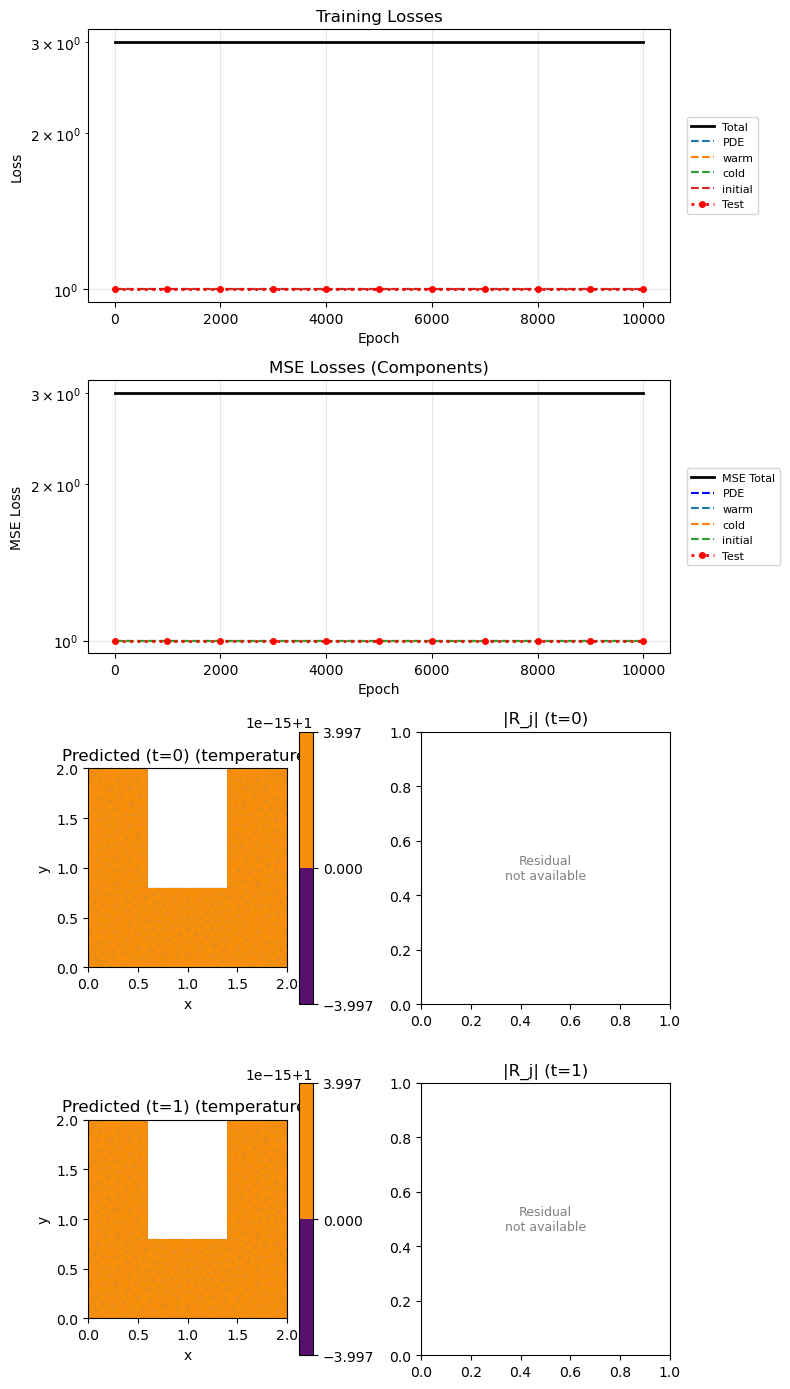

Epoch 0/10000 | Loss: 3.00e+00 | MSE Loss: 3.00e+00 | PDE: 1.00e+00 | BCs: [warm: 0.00e+00, cold: 1.00e+00, initial: 1.00e+00] | Time: 0.0s | Test Loss: 1.00e+00
Epoch 1000/10000 | Loss: 3.00e+00 | MSE Loss: 3.00e+00 | PDE: 1.00e+00 | BCs: [warm: 0.00e+00, cold: 1.00e+00, initial: 1.00e+00] | Time: 14.2s | Test Loss: 1.00e+00
Epoch 2000/10000 | Loss: 3.00e+00 | MSE Loss: 3.00e+00 | PDE: 1.00e+00 | BCs: [warm: 0.00e+00, cold: 1.00e+00, initial: 1.00e+00] | Time: 23.5s | Test Loss: 1.00e+00
Epoch 3000/10000 | Loss: 3.00e+00 | MSE Loss: 3.00e+00 | PDE: 1.00e+00 | BCs: [warm: 0.00e+00, cold: 1.00e+00, initial: 1.00e+00] | Time: 32.7s | Test Loss: 1.00e+00
Epoch 4000/10000 | Loss: 3.00e+00 | MSE Loss: 3.00e+00 | PDE: 1.00e+00 | BCs: [warm: 0.00e+00, cold: 1.00e+00, initial: 1.00e+00] | Time: 42.0s | Test Loss: 1.00e+00
Epoch 5000/10000 | Loss: 3.00e+00 | MSE Loss: 3.00e+00 | PDE: 1.00e+00 | BCs: [warm: 0.00e+00, cold: 1.00e+00, initial: 1.00e+00] | Time: 51.3s | Test Loss: 1.00e+00
Epoch 60

In [11]:
trainer = pinns.Trainer(problem, model)

trainer.compile(
    problem={
        "pde" :   {"train": 1000, "test": 50, "weight": 1.0},
        "warm": {"train": 100, "test": 0, "weight": 1.0},
        "cold":  {"train": 100, "test": 0, "weight": 1.0},
        "initial":    {"train": 100, "test": 0, "weight": 1.0}
    },
    schedulers=[
        pinns.SchedulerResample(10)
    ],
    optimizer=pinns.SOAPOptimizer(),
    epochs=10000,
    print_each=1000,    
)

trainer.train()